In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [109]:
df = pd.read_csv('/content/Exam_Score_Prediction.csv')
df.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [110]:
df.shape

(20000, 13)

In [111]:
df.columns

Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='object')

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        20000 non-null  int64  
 1   age               20000 non-null  int64  
 2   gender            20000 non-null  object 
 3   course            20000 non-null  object 
 4   study_hours       20000 non-null  float64
 5   class_attendance  20000 non-null  float64
 6   internet_access   20000 non-null  object 
 7   sleep_hours       20000 non-null  float64
 8   sleep_quality     20000 non-null  object 
 9   study_method      20000 non-null  object 
 10  facility_rating   20000 non-null  object 
 11  exam_difficulty   20000 non-null  object 
 12  exam_score        20000 non-null  float64
dtypes: float64(4), int64(2), object(7)
memory usage: 2.0+ MB


In [113]:
df.isnull().sum()

,0
student_id,0
age,0
gender,0
course,0
study_hours,0
class_attendance,0
internet_access,0
sleep_hours,0
sleep_quality,0
study_method,0


In [114]:
df.duplicated().sum()

np.int64(0)

### 1. Drop `student_id` column

In [115]:
df = df.drop('student_id', axis=1)
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


### 2. Exploratory Data Analysis (EDA) on `exam_score`

Let's first look at the distribution of our target variable, `exam_score`.

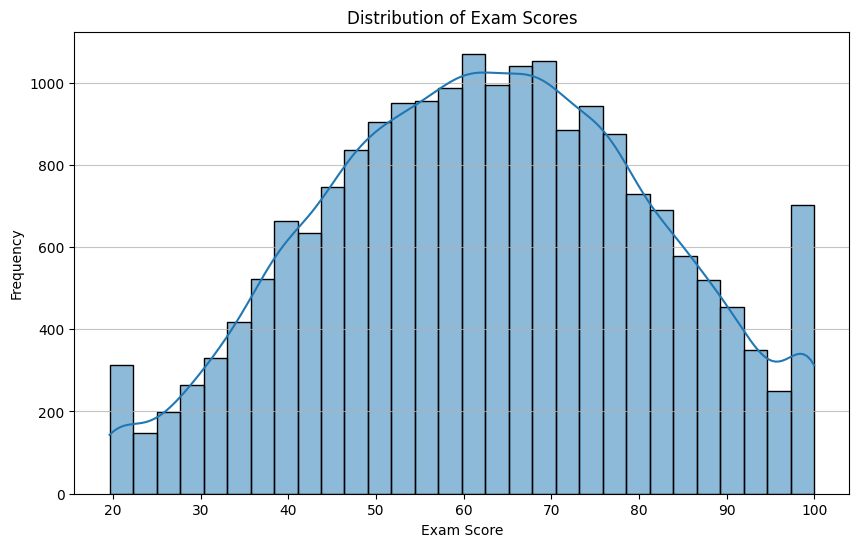

In [116]:
plt.figure(figsize=(10, 6))
sns.histplot(df['exam_score'], kde=True, bins=30)
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

### 3. Analyze Numerical Features

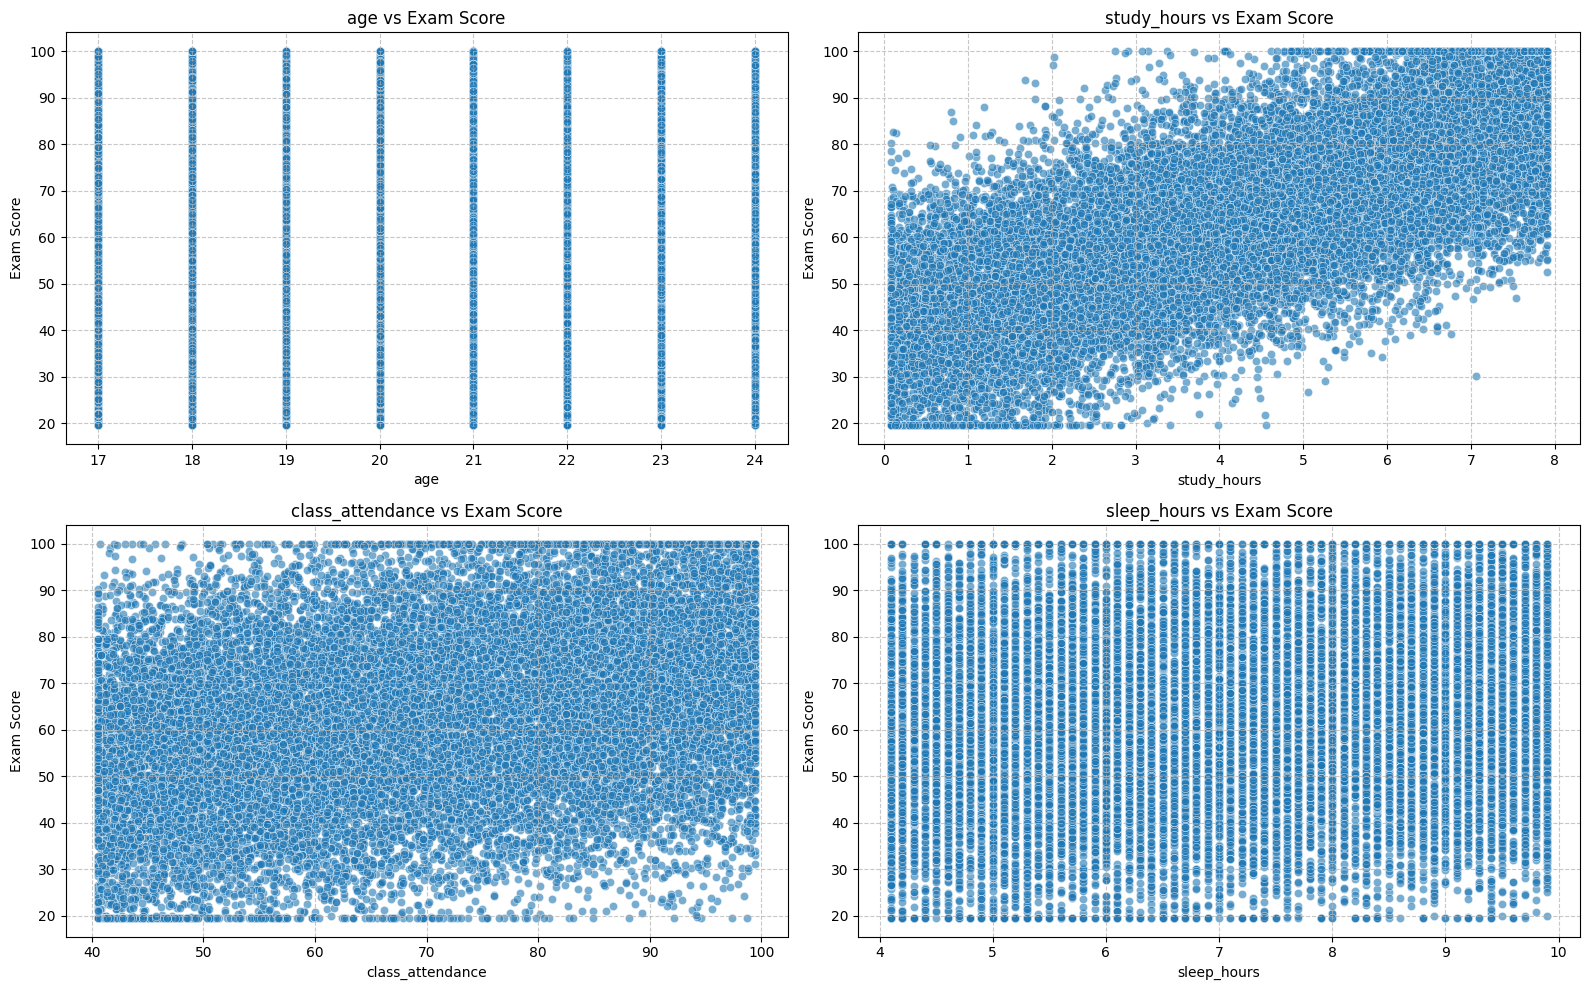

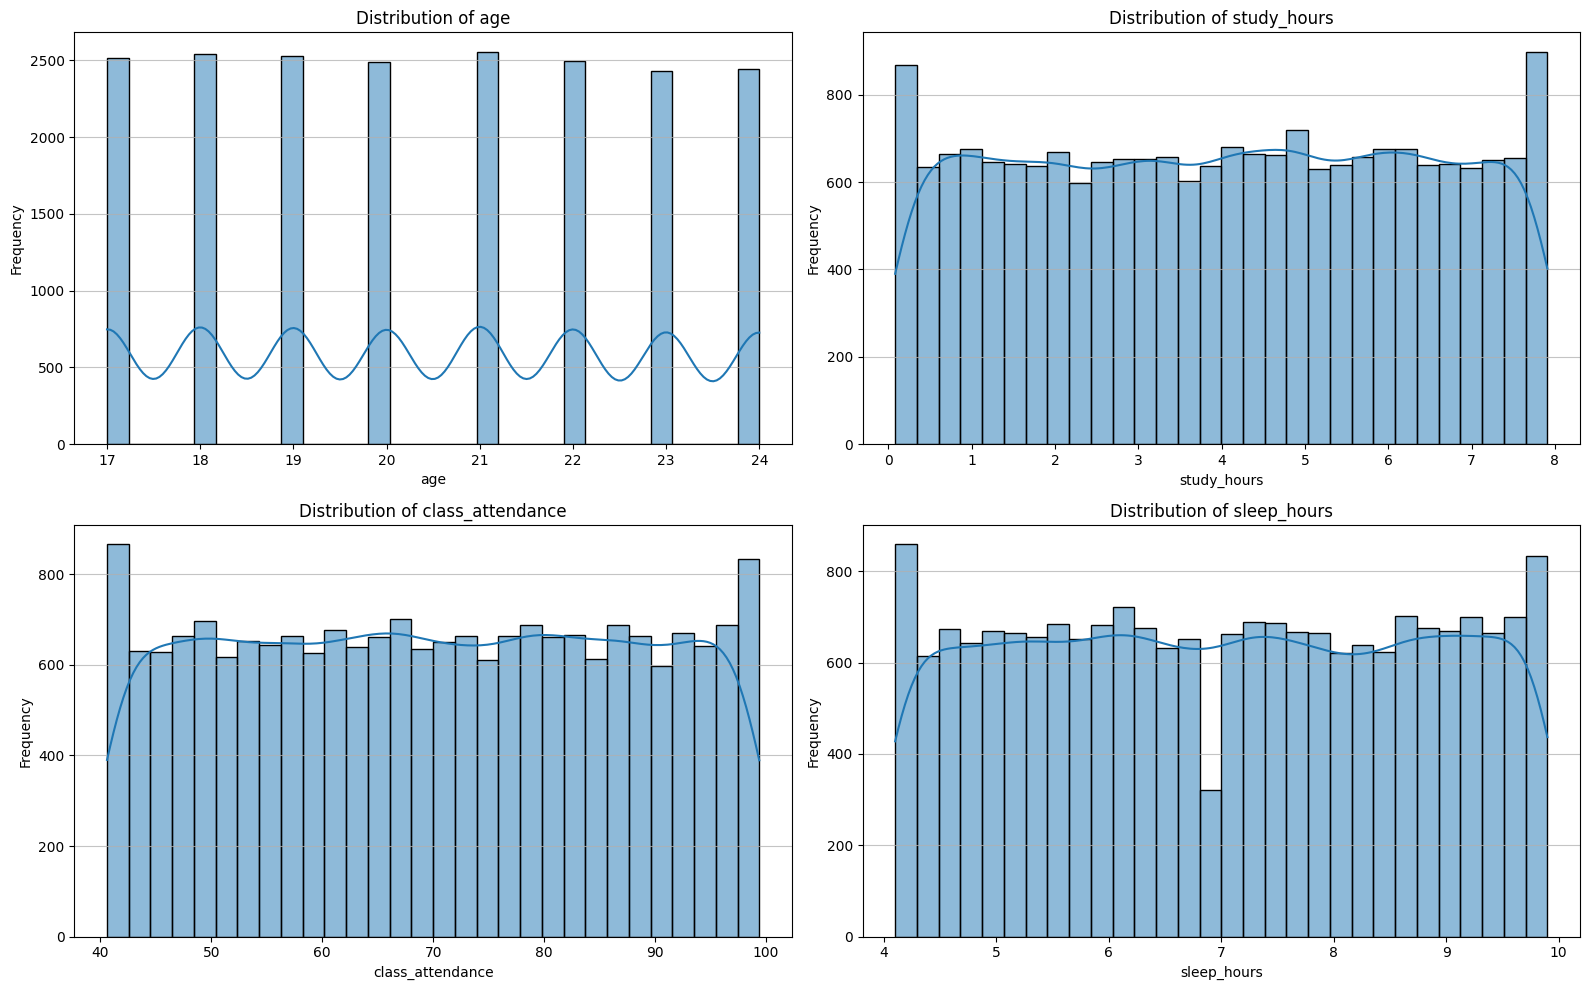

In [117]:
numerical_cols = ['age', 'study_hours', 'class_attendance', 'sleep_hours']

plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x=df[col], y=df['exam_score'], alpha=0.6)
    plt.title(f'{col} vs Exam Score')
    plt.xlabel(col)
    plt.ylabel('Exam Score')
    plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### 3.1 Correlation Heatmap of Numerical Features

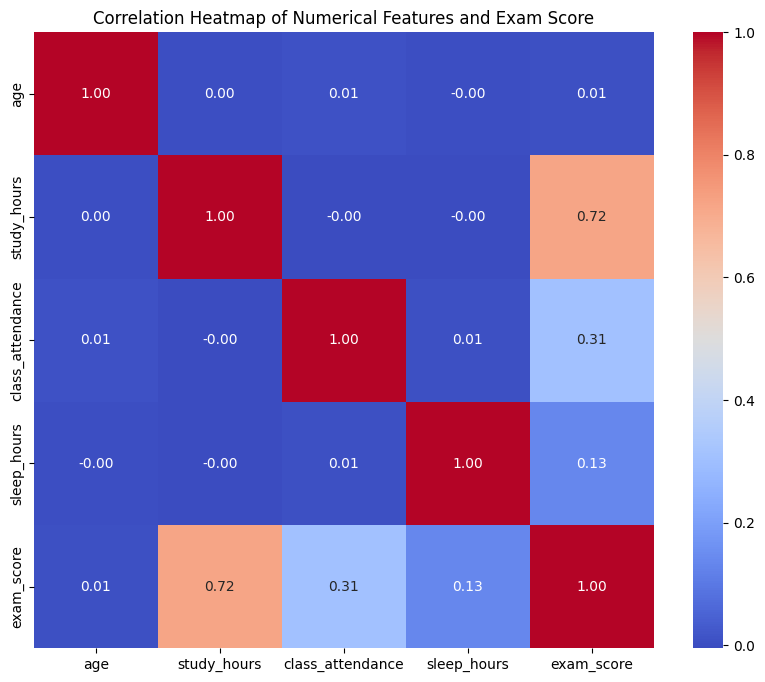

In [118]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols + ['exam_score']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features and Exam Score')
plt.show()

### 4. Analyze Categorical Features

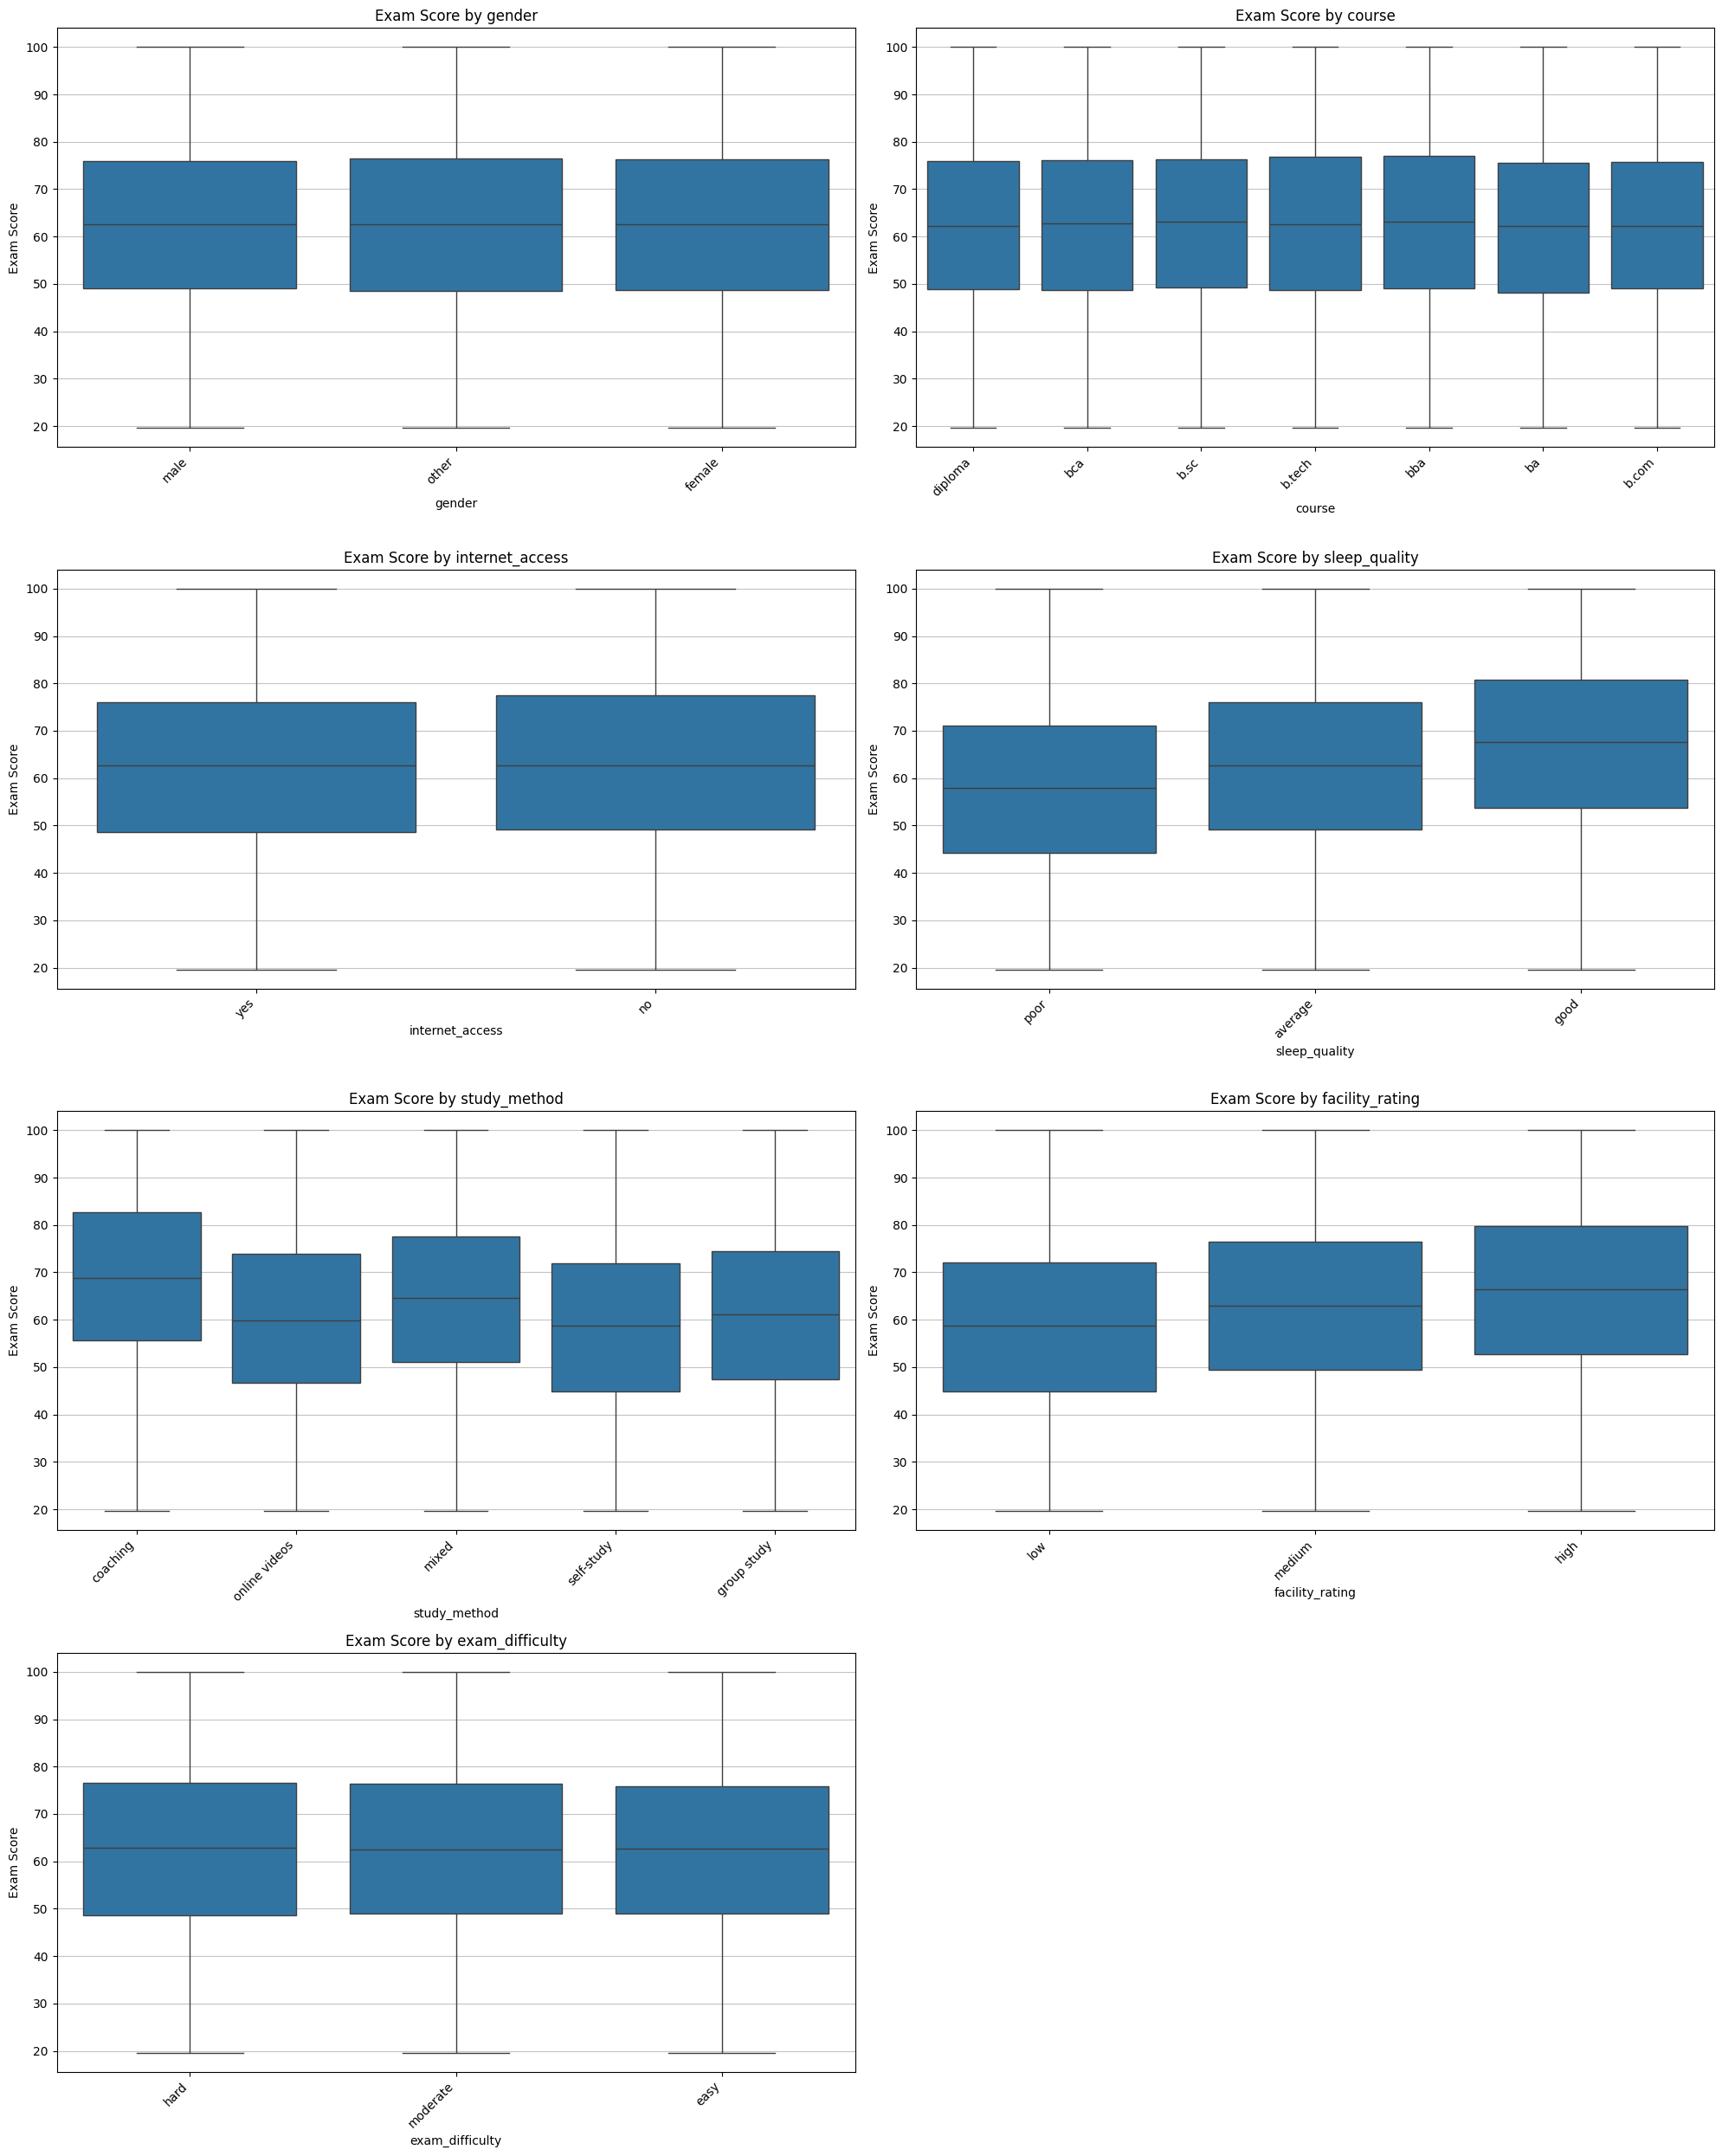

In [119]:
categorical_cols = ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

plt.figure(figsize=(20, 25))
for i, col in enumerate(categorical_cols):
    plt.subplot(4, 2, i + 1)
    sns.boxplot(x=col, y='exam_score', data=df)
    plt.title(f'Exam Score by {col}')
    plt.xlabel(col)
    plt.ylabel('Exam Score')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### 5. Statistical Tests on Categorical Variables (including Age)

We will use ANOVA (Analysis of Variance) to determine if there are significant differences in `exam_score` means across the categories of each variable. A low p-value (typically < 0.05) indicates that there is a statistically significant difference between at least two group means.

In [120]:
from scipy import stats

# Include 'age' in the list of columns for statistical testing as requested
statistical_test_cols = categorical_cols + ['age']

print("ANOVA Test Results for Exam Score by Categorical Variables:")
print("-----------------------------------------------------------")

for col in statistical_test_cols:
    # Get unique categories in the column
    categories = df[col].unique()

    # Prepare lists of exam scores for each category
    groups = [df['exam_score'][df[col] == cat] for cat in categories]

    # Perform one-way ANOVA test
    f_statistic, p_value = stats.f_oneway(*groups)

    print(f"Variable: {col}")
    print(f"  F-statistic: {f_statistic:.2f}")
    print(f"  P-value: {p_value:.3f}")

    if p_value < 0.05:
        print("  -> There is a statistically significant difference in exam scores across categories.\n")
    else:
        print("  -> No statistically significant difference in exam scores across categories.\n")

ANOVA Test Results for Exam Score by Categorical Variables:
-----------------------------------------------------------
Variable: gender
  F-statistic: 0.19
  P-value: 0.826
  -> No statistically significant difference in exam scores across categories.

Variable: course
  F-statistic: 0.61
  P-value: 0.719
  -> No statistically significant difference in exam scores across categories.

Variable: internet_access
  F-statistic: 1.22
  P-value: 0.268
  -> No statistically significant difference in exam scores across categories.

Variable: sleep_quality
  F-statistic: 411.79
  P-value: 0.000
  -> There is a statistically significant difference in exam scores across categories.

Variable: study_method
  F-statistic: 180.53
  P-value: 0.000
  -> There is a statistically significant difference in exam scores across categories.

Variable: facility_rating
  F-statistic: 273.77
  P-value: 0.000
  -> There is a statistically significant difference in exam scores across categories.

Variable: exam_

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               20000 non-null  int64  
 1   gender            20000 non-null  object 
 2   course            20000 non-null  object 
 3   study_hours       20000 non-null  float64
 4   class_attendance  20000 non-null  float64
 5   internet_access   20000 non-null  object 
 6   sleep_hours       20000 non-null  float64
 7   sleep_quality     20000 non-null  object 
 8   study_method      20000 non-null  object 
 9   facility_rating   20000 non-null  object 
 10  exam_difficulty   20000 non-null  object 
 11  exam_score        20000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 1.8+ MB


#   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               20000 non-null  int64 ❌

 1   gender            20000 non-null  object ❌

 2   course            20000 non-null  object ⏫

 3   study_hours       20000 non-null  float64 ✅

 4   class_attendance  20000 non-null  float64 ✅

 5   internet_access   20000 non-null  object ❌

 6   sleep_hours       20000 non-null  float64 ✅

 7   sleep_quality     20000 non-null  object ✅

 8   study_method      20000 non-null  object ✅

 9   facility_rating   20000 non-null  object ✅

 10  exam_difficulty   20000 non-null  object ❌

 11  exam_score        20000 non-null  float64 ✅

### 7. Label Encoding for Independent Categorical Variables

In [122]:
from sklearn.preprocessing import LabelEncoder

# Apply Label Encoding directly to the original 'df'
independent_categorical_cols = [col for col in categorical_cols if col in df.columns]

for col in independent_categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    print(f"Label Encoded column in-place: {col}")

display(df.head())

Label Encoded column in-place: gender
Label Encoded column in-place: course
Label Encoded column in-place: internet_access
Label Encoded column in-place: sleep_quality
Label Encoded column in-place: study_method
Label Encoded column in-place: facility_rating
Label Encoded column in-place: exam_difficulty


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,1,6,2.78,92.9,1,7.4,2,0,1,1,58.9
1,23,2,5,3.37,64.8,1,4.6,0,3,2,2,54.8
2,22,1,1,7.88,76.8,1,8.5,2,0,0,2,90.3
3,20,2,6,0.67,48.4,1,5.8,0,3,1,2,29.7
4,20,0,6,0.89,71.6,1,9.8,2,0,1,2,43.7


In [123]:
df

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,1,6,2.78,92.9,1,7.4,2,0,1,1,58.9
1,23,2,5,3.37,64.8,1,4.6,0,3,2,2,54.8
2,22,1,1,7.88,76.8,1,8.5,2,0,0,2,90.3
3,20,2,6,0.67,48.4,1,5.8,0,3,1,2,29.7
4,20,0,6,0.89,71.6,1,9.8,2,0,1,2,43.7
...,...,...,...,...,...,...,...,...,...,...,...,...
19995,18,2,4,6.50,71.3,1,5.0,1,4,1,0,86.5
19996,18,1,0,3.71,41.6,0,5.9,0,0,2,2,60.9
19997,19,2,6,7.88,68.2,1,4.6,2,1,1,0,64.5
19998,19,1,4,4.60,76.3,0,6.1,1,4,2,2,79.0


In [124]:
X = df.drop(['exam_score','age','gender','internet_access','exam_difficulty','course'],axis = 1)
y = df['exam_score']

In [125]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [126]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [127]:
# Initialize the Decision Tree Regressor with a random state
dt_model = DecisionTreeRegressor(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dt_model.predict(X_test)

# Evaluate the performance
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Display the results
print("Decision Tree Regressor Performance Metrics:")
print("------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE):  {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2 Score):      {r2:.4f}")

Decision Tree Regressor Performance Metrics:
------------------------------------------
Mean Absolute Error (MAE): 11.7722
Mean Squared Error (MSE):  218.0949
Root Mean Squared Error (RMSE): 14.7680
R-squared (R2 Score):      0.3903


In [128]:
from sklearn.ensemble import AdaBoostRegressor

In [129]:
# Initialize the AdaBoostRegressor with a random state for reproducibility
ada_model = AdaBoostRegressor(random_state=42)

# Train the model
ada_model.fit(X_train, y_train)

# Make predictions
y_pred_ada = ada_model.predict(X_test)

# Calculate metrics
mse_ada = mean_squared_error(y_test, y_pred_ada)
rmse_ada = np.sqrt(mse_ada)
mae_ada = mean_absolute_error(y_test, y_pred_ada)
r2_ada = r2_score(y_test, y_pred_ada)

# Print metrics
print("AdaBoost Regressor Performance Metrics:")
print("-------------------------------------")
print(f"Mean Absolute Error (MAE): {mae_ada:.4f}")
print(f"Mean Squared Error (MSE):  {mse_ada:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_ada:.4f}")
print(f"R-squared (R2 Score):      {r2_ada:.4f}")

AdaBoost Regressor Performance Metrics:
-------------------------------------
Mean Absolute Error (MAE): 8.8908
Mean Squared Error (MSE):  118.1829
Root Mean Squared Error (RMSE): 10.8712
R-squared (R2 Score):      0.6696


In [130]:
from xgboost import XGBRegressor

# Initialize the XGBRegressor with a random state
xgb_model = XGBRegressor(random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Calculate metrics
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

# Print metrics
print("XGBoost Regressor Performance Metrics:")
print("-------------------------------------")
print(f"Mean Absolute Error (MAE): {mae_xgb:.4f}")
print(f"Mean Squared Error (MSE):  {mse_xgb:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.4f}")
print(f"R-squared (R2 Score):      {r2_xgb:.4f}")

XGBoost Regressor Performance Metrics:
-------------------------------------
Mean Absolute Error (MAE): 8.3566
Mean Squared Error (MSE):  108.3619
Root Mean Squared Error (RMSE): 10.4097
R-squared (R2 Score):      0.6971


In [131]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0]
}

# Initialize Grid Search with 3-fold cross-validation
grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search to the training data
grid_search.fit(X_train, y_train)

# Get the best estimator
best_xgb_model = grid_search.best_estimator_

# Make predictions with the best model
y_pred_best = best_xgb_model.predict(X_test)

# Calculate metrics for the best model
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

# Display the results
print("Grid Search Complete!")
print("-------------------------------------")
print("Best Parameters Found:", grid_search.best_params_)
print("-------------------------------------")
print("Tuned XGBoost Regressor Performance Metrics:")
print(f"Mean Absolute Error (MAE): {mae_best:.4f}")
print(f"Mean Squared Error (MSE):  {mse_best:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_best:.4f}")
print(f"R-squared (R2 Score):      {r2_best:.4f}")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Grid Search Complete!
-------------------------------------
Best Parameters Found: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
-------------------------------------
Tuned XGBoost Regressor Performance Metrics:
Mean Absolute Error (MAE): 7.9416
Mean Squared Error (MSE):  96.9317
Root Mean Squared Error (RMSE): 9.8454
R-squared (R2 Score):      0.7290


In [133]:
import pickle
from sklearn.preprocessing import LabelEncoder

# 1. Save the best XGBoost model separately
with open('best_xgb_model.pkl', 'wb') as f:
    pickle.dump(best_xgb_model, f)

# 2. Fit the label encoders and save them separately in their own dictionary
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    raw_df = pd.read_csv('/content/Exam_Score_Prediction.csv')
    le.fit(raw_df[col])
    encoders[col] = le

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("Saved successfully!")
print("- Model saved to 'best_xgb_model.pkl'")
print("- Label encoders saved to 'label_encoders.pkl'")

Saved successfully!
- Model saved to 'best_xgb_model.pkl'
- Label encoders saved to 'label_encoders.pkl'
